##**Importing necessary libraries**

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import display

##**Setting visualization style**

In [ ]:
# Set visualization style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('deep')
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['figure.dpi'] = 100

##**Loading the cleaned data**

In [ ]:
# Load the cleaned data
# df = pd.read_csv('data/processed/online_retail_cleaned.csv')
from google.colab import files
uploaded = files.upload()
df = pd.read_csv('online_retail_cleaned.csv')

Saving online_retail_cleaned.csv to online_retail_cleaned.csv


##**Converting InvoiceDate back to datetime**

In [ ]:
# Convert InvoiceDate back to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print(f"Dataset shape: {df.shape}")
print(f"Date range: {df['InvoiceDate'].min()} to {df['InvoiceDate'].max()}")
print(f"Number of unique customers: {df['Customer ID'].nunique()}")
print(f"Number of unique products: {df['StockCode'].nunique()}")
print(f"Number of unique invoices: {df['Invoice'].nunique()}")
print(f"Number of countries: {df['Country'].nunique()}")

Dataset shape: (390260, 14)
Date range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00
Number of unique customers: 4290
Number of unique products: 3626
Number of unique invoices: 17980
Number of countries: 37


##**Analyzing sales trends over time**

In [ ]:
# 1. Analyze sales trends over time
# Aggregate daily sales
daily_sales = df.groupby(df['InvoiceDate'].dt.date).agg({
    'Quantity': 'sum',
    'TotalAmount': 'sum',
    'Invoice': pd.Series.nunique,
    'Customer ID': pd.Series.nunique
}).reset_index()

daily_sales.columns = ['Date', 'TotalQuantity', 'TotalSales', 'NumberOfTransactions', 'NumberOfCustomers']


##**Plotting daily sales**

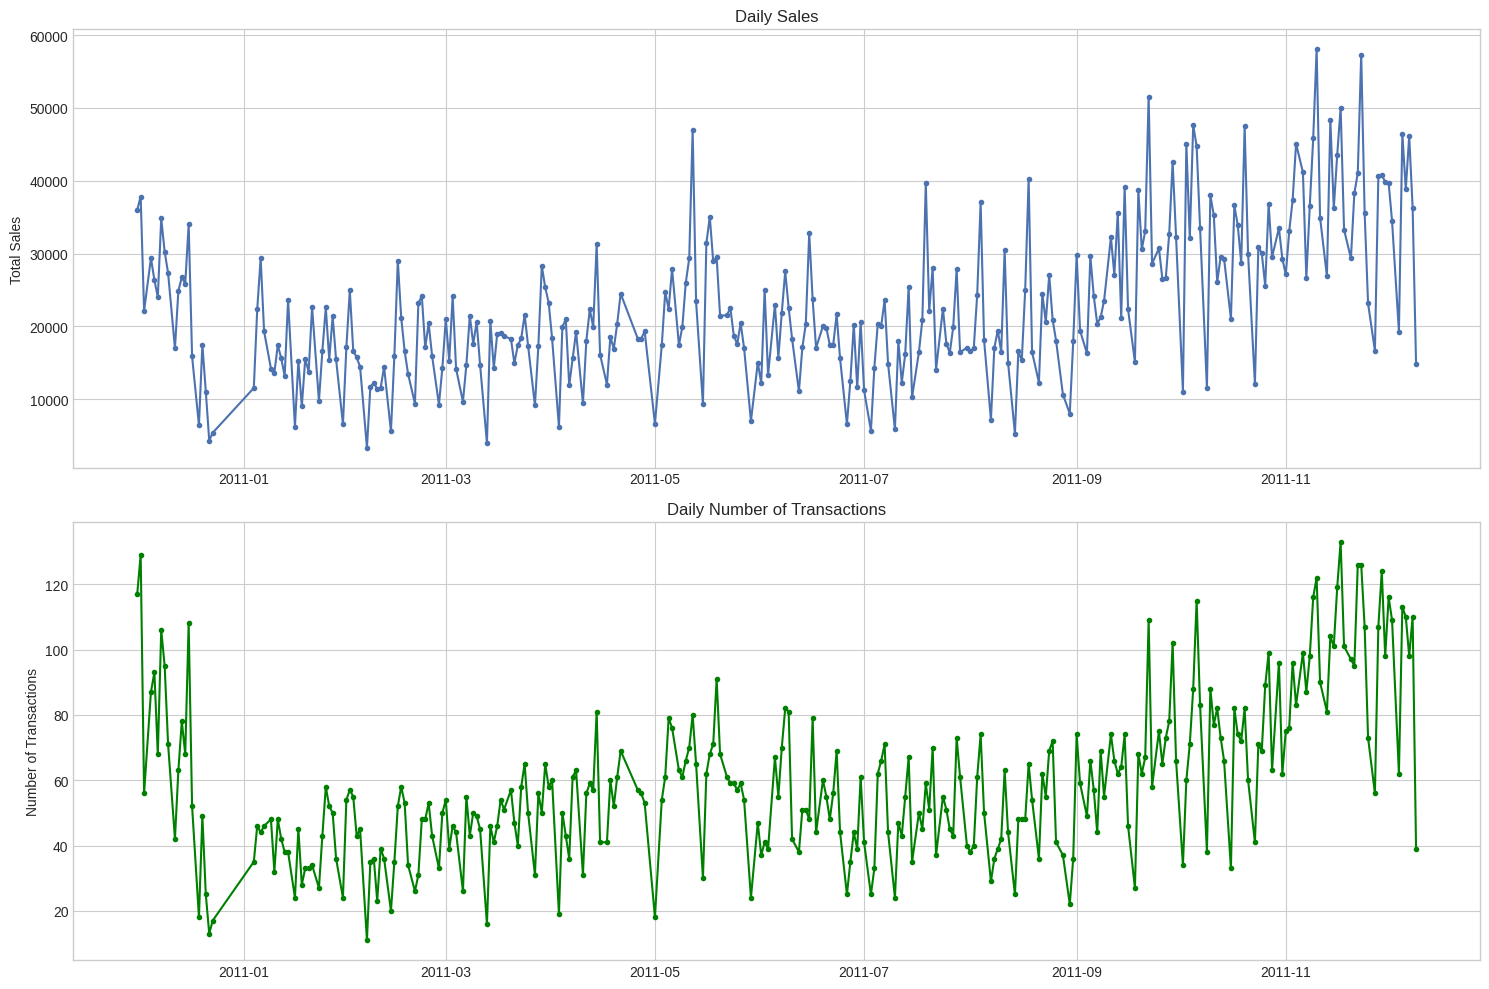

In [ ]:
# Plot daily sales
plt.figure(figsize=(15, 10))

plt.subplot(2, 1, 1)
plt.plot(daily_sales['Date'], daily_sales['TotalSales'], marker='o', linestyle='-', markersize=3)
plt.title('Daily Sales')
plt.ylabel('Total Sales')
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(daily_sales['Date'], daily_sales['NumberOfTransactions'], marker='o', linestyle='-', markersize=3, color='green')
plt.title('Daily Number of Transactions')
plt.ylabel('Number of Transactions')
plt.grid(True)

plt.tight_layout()
plt.show()


##**Monthly sales trends**

In [ ]:
# Monthly sales trends
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')
monthly_sales = df.groupby('YearMonth').agg({
    'TotalAmount': 'sum',
    'Invoice': pd.Series.nunique,
    'Customer ID': pd.Series.nunique
}).reset_index()

monthly_sales['YearMonth'] = monthly_sales['YearMonth'].astype(str)

fig = make_subplots(rows=2, cols=1, subplot_titles=('Monthly Sales', 'Monthly Number of Customers'))

fig.add_trace(
    go.Bar(x=monthly_sales['YearMonth'], y=monthly_sales['TotalAmount'], name='Total Sales'),
    row=1, col=1
)

fig.add_trace(
    go.Bar(x=monthly_sales['YearMonth'], y=monthly_sales['Customer ID'], name='Number of Customers', marker_color='green'),
    row=2, col=1
)

fig.update_layout(height=800, width=1000, title_text="Monthly Sales Analysis", showlegend=False)
fig.show()

##**Customer geographic distribution**


Top 10 Countries by Sales:


,Country,TotalSales,NumberOfCustomers,NumberOfTransactions,AverageOrderValue
35,United Kingdom,5737824.484,3875,16189,354.427357
10,EIRE,199929.610,3,253,790.235613
14,Germany,198645.810,94,441,450.444014
13,France,173829.620,87,377,461.086525
23,Netherlands,163557.520,8,83,1970.572530
0,Australia,79230.670,9,50,1584.613400
32,Switzerland,51727.590,21,47,1100.587021
30,Spain,43971.440,30,87,505.418851
3,Belgium,35763.160,25,97,368.692371
24,Norway,31238.130,10,34,918.768529


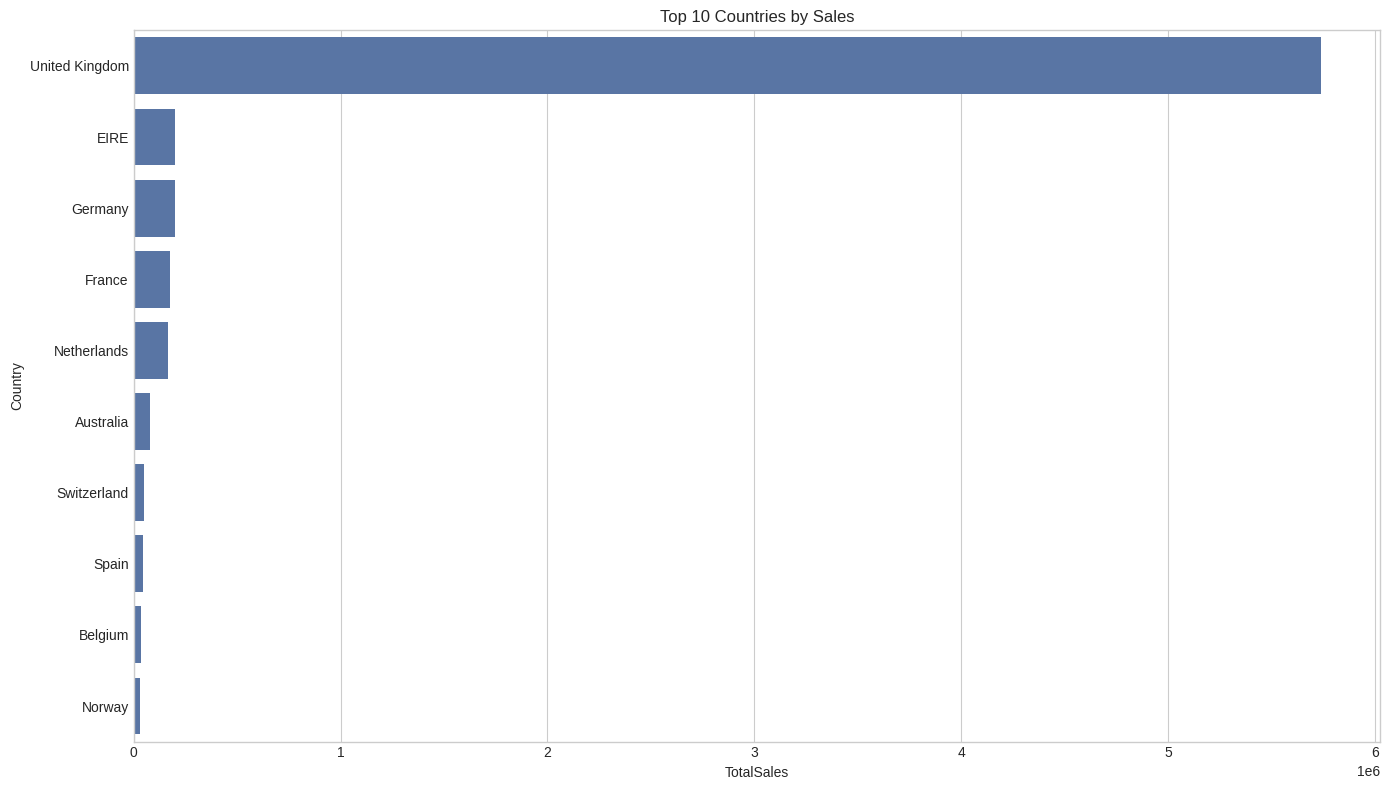

In [ ]:
# 2. Customer geographic distribution
country_sales = df.groupby('Country').agg({
    'TotalAmount': 'sum',
    'Customer ID': pd.Series.nunique,
    'Invoice': pd.Series.nunique
}).reset_index()

country_sales.columns = ['Country', 'TotalSales', 'NumberOfCustomers', 'NumberOfTransactions']
country_sales = country_sales.sort_values('TotalSales', ascending=False)

# Calculate average order value by country
country_sales['AverageOrderValue'] = country_sales['TotalSales'] / country_sales['NumberOfTransactions']

# Display top 10 countries by sales
print("\nTop 10 Countries by Sales:")
display(country_sales.head(10))

# Plot top 10 countries by sales
plt.figure(figsize=(14, 8))
sns.barplot(x='TotalSales', y='Country', data=country_sales.head(10))
plt.title('Top 10 Countries by Sales')
plt.tight_layout()
plt.show()

##**Product analysis**


Top 20 Products by Sales:


,StockCode,Description,TotalQuantity,TotalSales,NumberOfCustomers
1308,22423,REGENCY CAKESTAND 3 TIER,11191,129122.35,880
3416,85123A,WHITE HANGING HEART T-LIGHT HOLDER,23417,64039.11,852
2766,47566,PARTY BUNTING,13441,61166.83,706
3401,85099B,JUMBO BAG RED RETROSPOT,29971,56880.88,630
3238,84879,ASSORTED COLOUR BIRD ORNAMENT,22154,37428.74,663
2927,79321,CHILLI LIGHTS,7482,36751.47,204
991,22086,PAPER CHAIN KIT 50'S CHRISTMAS,12745,35337.23,611
2236,23298,SPOTTY BUNTING,6443,30575.85,570
1835,22960,JAM MAKING SET WITH JARS,7565,30038.77,573
1982,23084,RABBIT NIGHT LIGHT,14230,27158.88,449


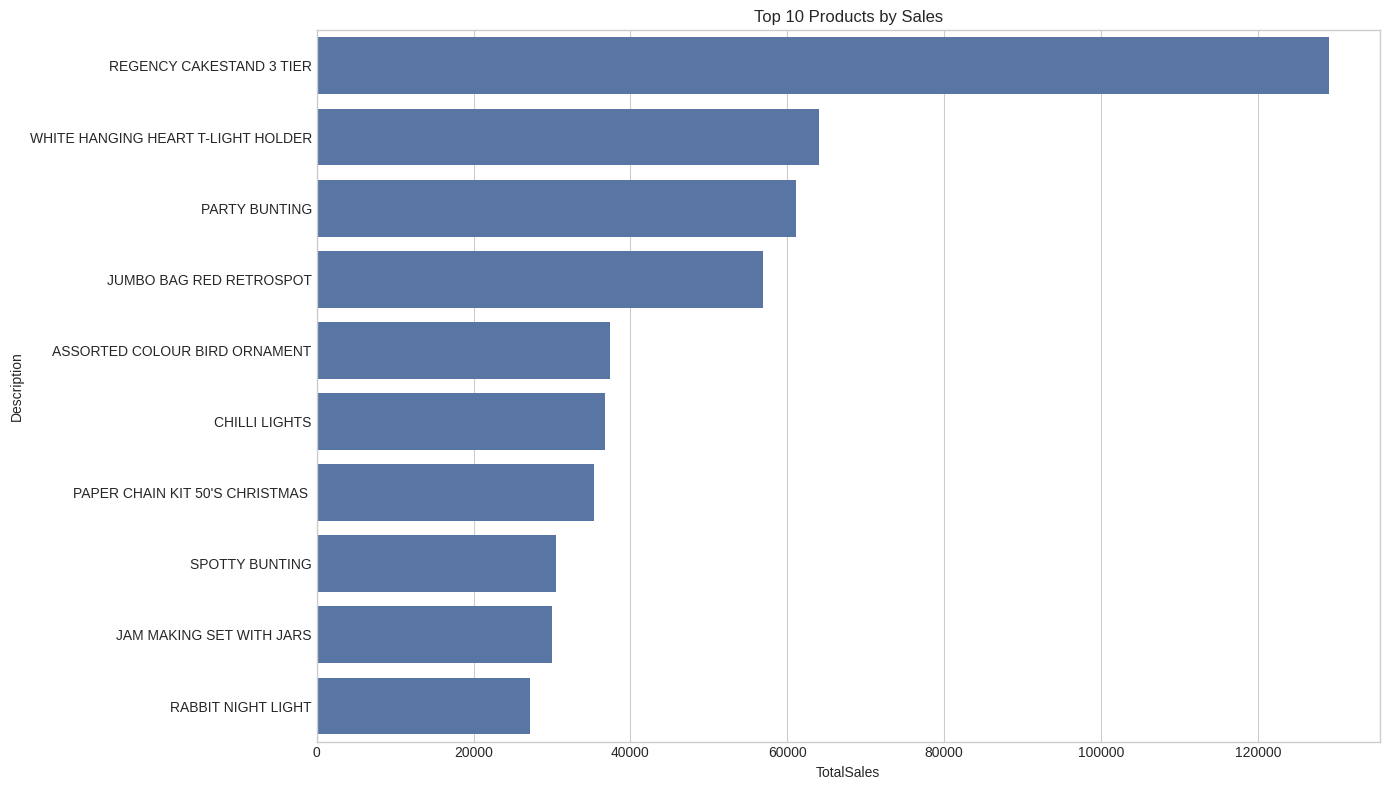

In [ ]:
# 3. Product analysis
product_sales = df.groupby(['StockCode', 'Description']).agg({
    'Quantity': 'sum',
    'TotalAmount': 'sum',
    'Customer ID': pd.Series.nunique
}).reset_index()

product_sales.columns = ['StockCode', 'Description', 'TotalQuantity', 'TotalSales', 'NumberOfCustomers']
product_sales = product_sales.sort_values('TotalSales', ascending=False)

# Display top 20 products by sales
print("\nTop 20 Products by Sales:")
display(product_sales.head(20))

# Plot top 10 products by sales
plt.figure(figsize=(14, 8))
top_products = product_sales.head(10)
sns.barplot(x='TotalSales', y='Description', data=top_products)
plt.title('Top 10 Products by Sales')
plt.tight_layout()
plt.show()

##**Customer purchase behavior**


Customer Behavior Statistics:


<ipython-input-10-537c5ccdeb3f>:2: FutureWarning:

The provided callable <built-in function min> is currently using SeriesGroupBy.min. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "min" instead.

<ipython-input-10-537c5ccdeb3f>:2: FutureWarning:

The provided callable <built-in function max> is currently using SeriesGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.



,Customer ID,NumberOfTransactions,TotalSpend,FirstPurchaseDate,LastPurchaseDate,CustomerLifetimeDays,AverageOrderValue
count,4290.000000,4290.000000,4290.000000,4290,4290,4290.000000,4290.000000
mean,15293.093706,4.191142,1613.083600,2011-05-01 02:42:59.762237952,2011-09-08 10:42:20.923076864,130.010956,344.331747
min,12347.000000,1.000000,2.900000,2010-12-01 08:26:00,2010-12-01 09:53:00,0.000000,2.900000
25%,13811.250000,1.000000,290.210000,2011-01-17 12:51:00,2011-07-20 10:24:00,0.000000,169.438333
50%,15287.500000,2.000000,637.695000,2011-04-05 14:27:00,2011-10-20 10:22:00,91.000000,274.905000
75%,16772.500000,5.000000,1547.890000,2011-08-19 10:11:30,2011-11-22 10:55:15,251.750000,407.535538
max,18287.000000,205.000000,158967.800000,2011-12-09 12:16:00,2011-12-09 12:50:00,373.000000,8951.260000
std,1719.210823,7.465179,4820.581093,NaN,NaN,131.977303,353.253198


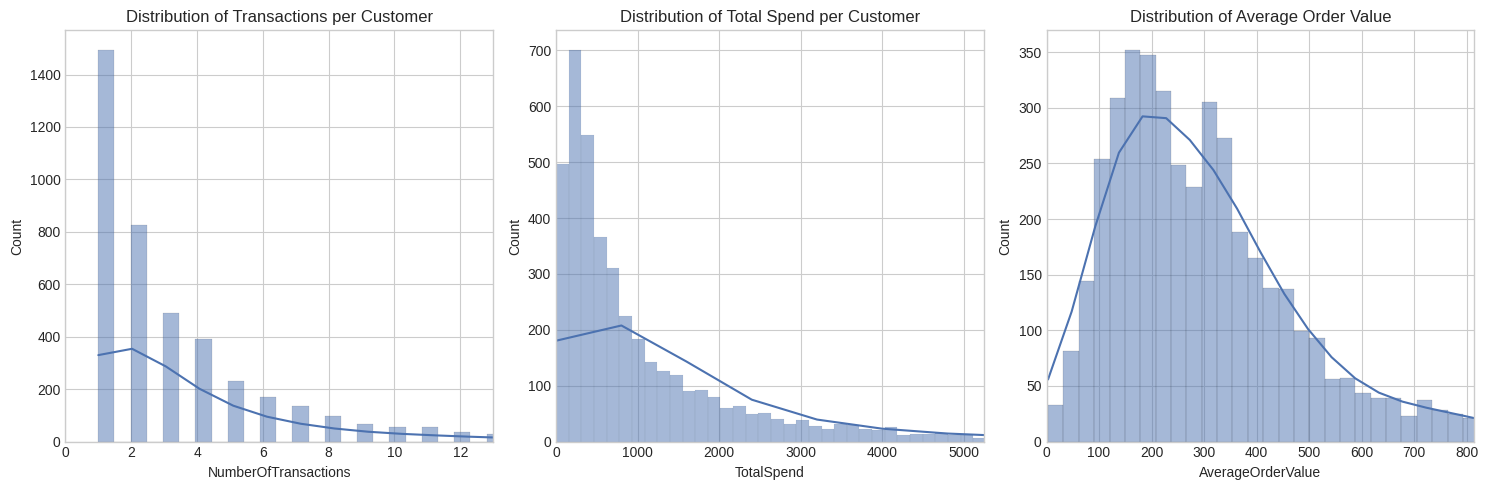

In [ ]:
# 4. Customer purchase behavior
customer_stats = df.groupby('Customer ID').agg({
    'Invoice': pd.Series.nunique,
    'TotalAmount': 'sum',
    'InvoiceDate': [min, max]
}).reset_index()

customer_stats.columns = ['Customer ID', 'NumberOfTransactions', 'TotalSpend', 'FirstPurchaseDate', 'LastPurchaseDate']

# Calculate days between first and last purchase
customer_stats['CustomerLifetimeDays'] = (customer_stats['LastPurchaseDate'] - customer_stats['FirstPurchaseDate']).dt.days
customer_stats['AverageOrderValue'] = customer_stats['TotalSpend'] / customer_stats['NumberOfTransactions']

# Display summary statistics for customer metrics
print("\nCustomer Behavior Statistics:")
display(customer_stats.describe())

# Plot distribution of purchases per customer
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.histplot(customer_stats['NumberOfTransactions'], kde=True)
plt.title('Distribution of Transactions per Customer')
plt.xlim(0, customer_stats['NumberOfTransactions'].quantile(0.95))

plt.subplot(1, 3, 2)
sns.histplot(customer_stats['TotalSpend'], kde=True)
plt.title('Distribution of Total Spend per Customer')
plt.xlim(0, customer_stats['TotalSpend'].quantile(0.95))

plt.subplot(1, 3, 3)
sns.histplot(customer_stats['AverageOrderValue'], kde=True)
plt.title('Distribution of Average Order Value')
plt.xlim(0, customer_stats['AverageOrderValue'].quantile(0.95))

plt.tight_layout()
plt.show()



##**Purchase frequency analysis**

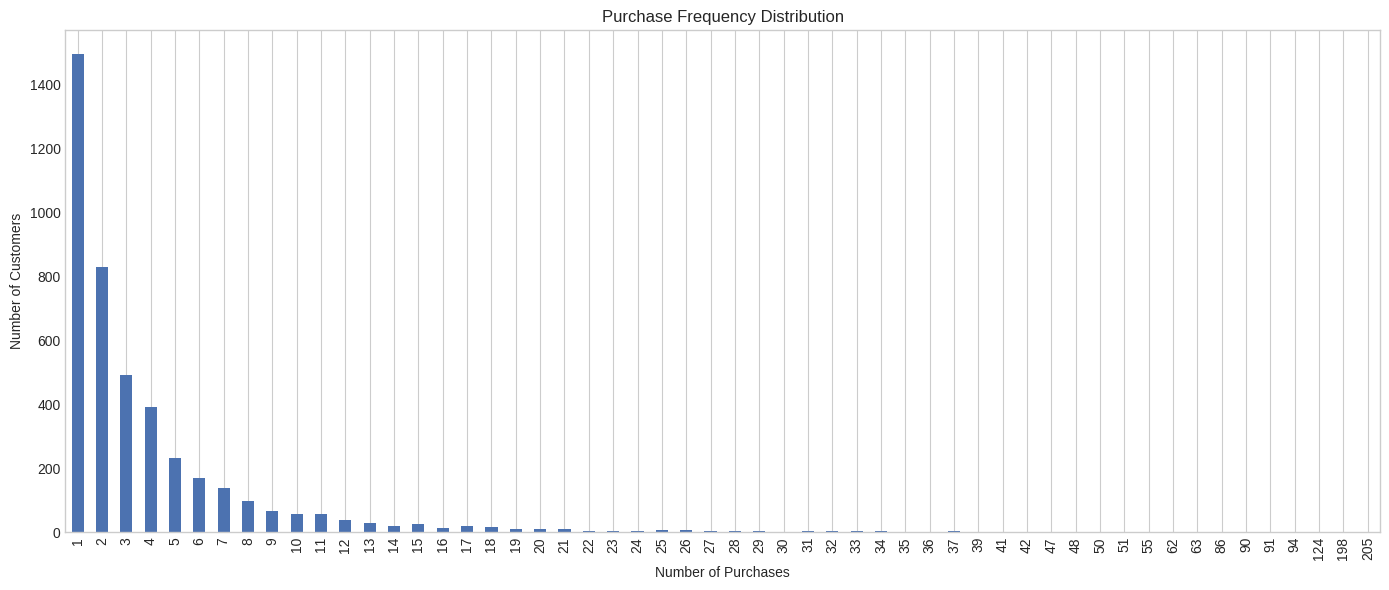

In [ ]:
# 5. Purchase frequency analysis
purchase_frequency = customer_stats['NumberOfTransactions'].value_counts().sort_index()

plt.figure(figsize=(14, 6))
purchase_frequency.plot(kind='bar')
plt.title('Purchase Frequency Distribution')
plt.xlabel('Number of Purchases')
plt.ylabel('Number of Customers')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

##**Time between purchases analysis**

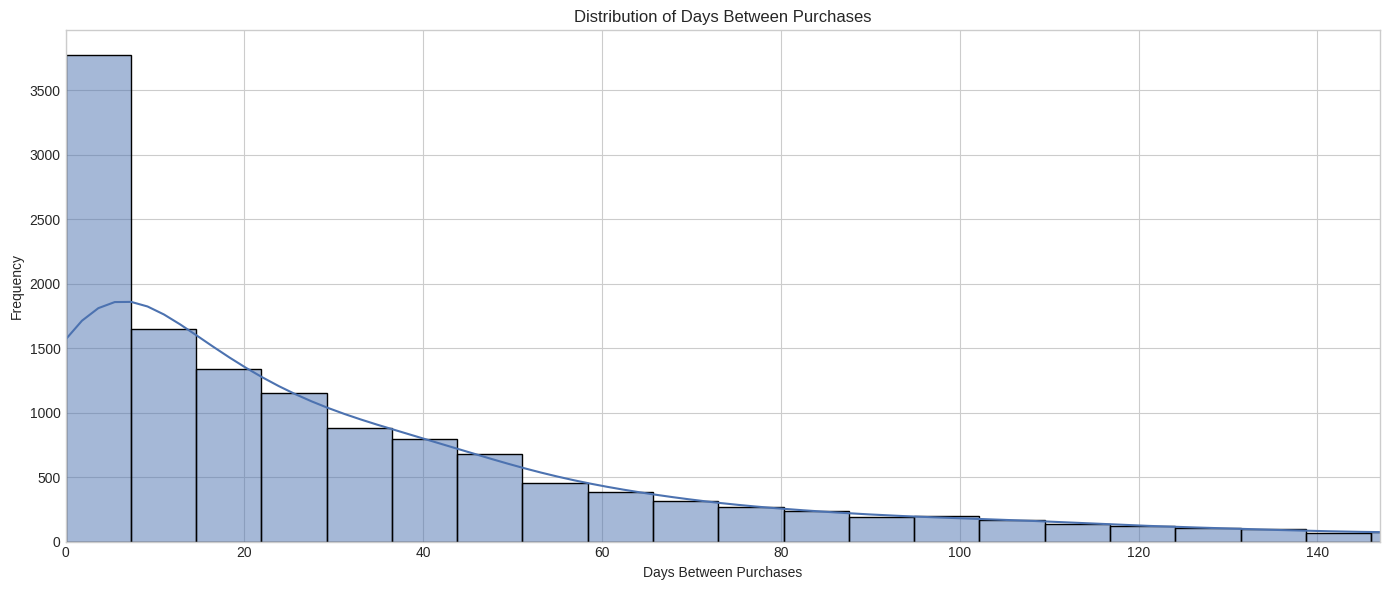


Average Time Between Purchases Statistics:


,Customer ID,AvgDaysBetweenPurchases
count,2798.000000,2798.000000
mean,15296.801287,72.819368
std,1713.884009,65.717126
min,12347.000000,0.000000
25%,13824.750000,29.666667
50%,15262.500000,53.366667
75%,16791.750000,92.583333
max,18287.000000,365.000000


In [ ]:
# 6. Time between purchases analysis
# Group transactions by customer and sort by date
customer_purchases = df.sort_values(['Customer ID', 'InvoiceDate'])
customer_purchases = customer_purchases.drop_duplicates(['Customer ID', 'Invoice', 'InvoiceDate'])

# Calculate time between purchases for each customer
customer_purchases['PreviousPurchaseDate'] = customer_purchases.groupby('Customer ID')['InvoiceDate'].shift(1)
customer_purchases['DaysBetweenPurchases'] = (customer_purchases['InvoiceDate'] - customer_purchases['PreviousPurchaseDate']).dt.days

# Remove first purchase for each customer (where previous purchase is NaN)
time_between_purchases = customer_purchases.dropna(subset=['DaysBetweenPurchases'])

plt.figure(figsize=(14, 6))
sns.histplot(time_between_purchases['DaysBetweenPurchases'], bins=50, kde=True)
plt.title('Distribution of Days Between Purchases')
plt.xlabel('Days Between Purchases')
plt.ylabel('Frequency')
plt.xlim(0, time_between_purchases['DaysBetweenPurchases'].quantile(0.95))
plt.tight_layout()
plt.show()

# Calculate average time between purchases for each customer
avg_time_between_purchases = time_between_purchases.groupby('Customer ID')['DaysBetweenPurchases'].mean().reset_index()
avg_time_between_purchases.columns = ['Customer ID', 'AvgDaysBetweenPurchases']

print("\nAverage Time Between Purchases Statistics:")
display(avg_time_between_purchases.describe())

##**Purchase patterns by day of week and hour**

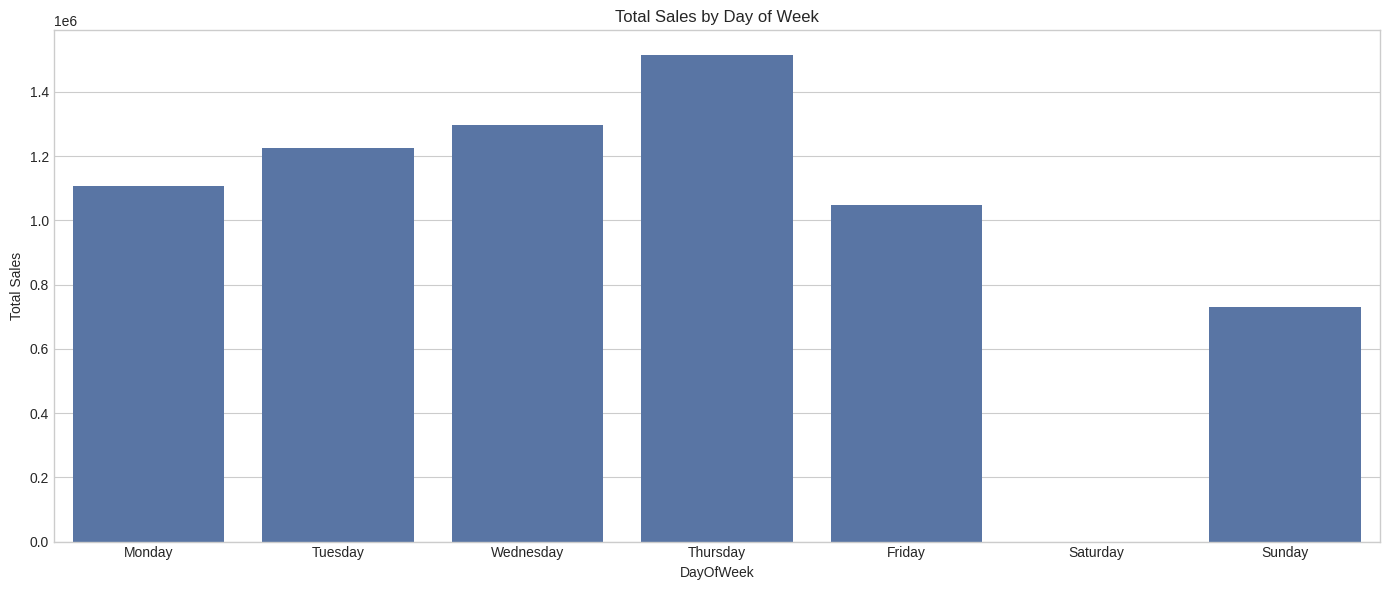

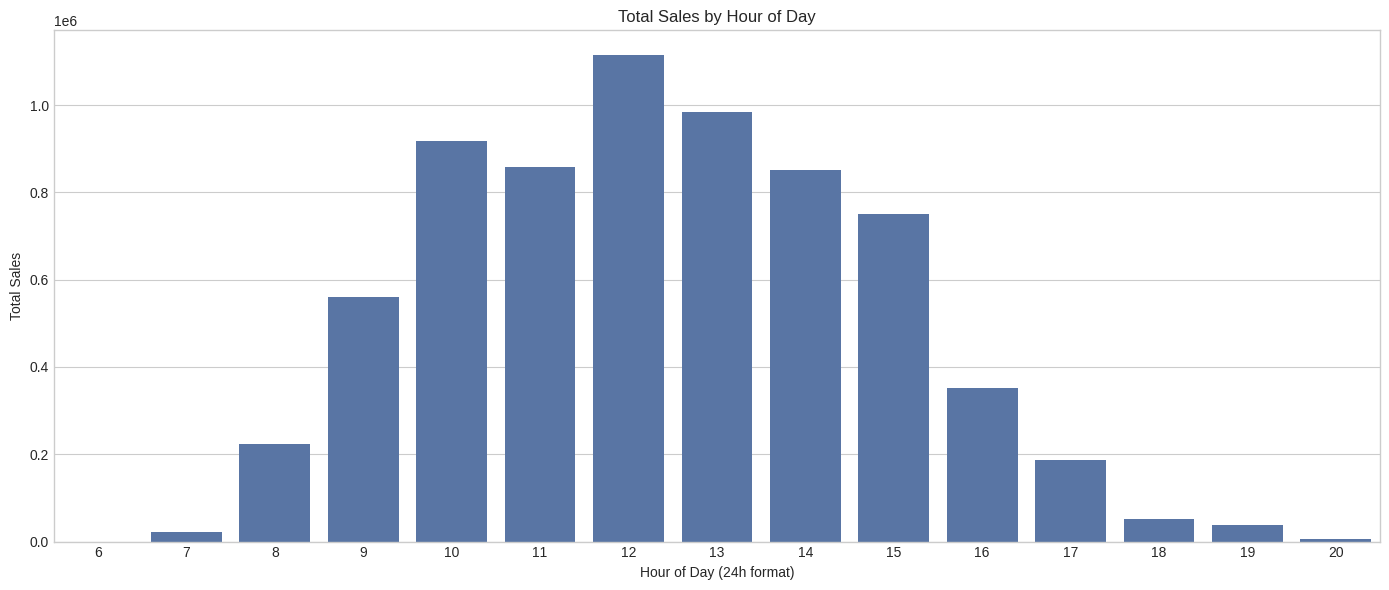

In [ ]:
# 7. Purchase patterns by day of week and hour
weekday_map = {0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday', 4: 'Friday', 5: 'Saturday', 6: 'Sunday'}
df['DayOfWeek'] = df['InvoiceDate'].dt.dayofweek.map(weekday_map)
df['Hour'] = df['InvoiceDate'].dt.hour

# Sales by day of week
day_of_week_sales = df.groupby('DayOfWeek').agg({
    'TotalAmount': 'sum',
    'Invoice': pd.Series.nunique,
    'Customer ID': pd.Series.nunique
}).reset_index()

# Ensure correct ordering of days
correct_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_of_week_sales['DayOfWeek'] = pd.Categorical(day_of_week_sales['DayOfWeek'], categories=correct_order, ordered=True)
day_of_week_sales = day_of_week_sales.sort_values('DayOfWeek')

# Plot sales by day of week
plt.figure(figsize=(14, 6))
sns.barplot(x='DayOfWeek', y='TotalAmount', data=day_of_week_sales)
plt.title('Total Sales by Day of Week')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()

# Sales by hour
hourly_sales = df.groupby('Hour').agg({
    'TotalAmount': 'sum',
    'Invoice': pd.Series.nunique,
    'Customer ID': pd.Series.nunique
}).reset_index()

# Plot sales by hour
plt.figure(figsize=(14, 6))
sns.barplot(x='Hour', y='TotalAmount', data=hourly_sales)
plt.title('Total Sales by Hour of Day')
plt.xlabel('Hour of Day (24h format)')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()

##**Heatmap of purchases by day and hour**

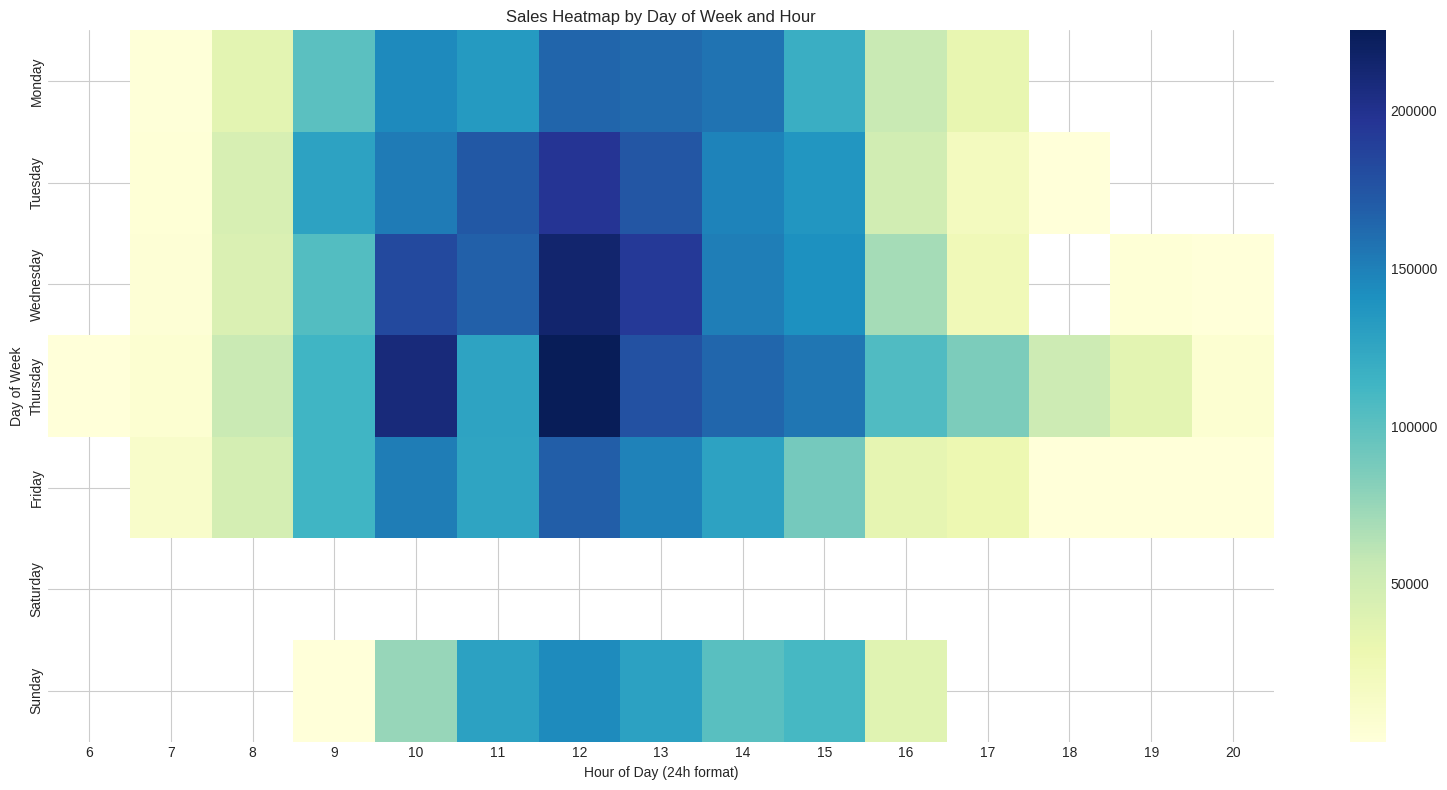

In [ ]:
# 8. Heatmap of purchases by day and hour
day_hour_sales = df.groupby(['DayOfWeek', 'Hour'])['TotalAmount'].sum().reset_index()
day_hour_pivot = day_hour_sales.pivot(index='DayOfWeek', columns='Hour', values='TotalAmount')

# Ensure all days are in correct order
day_hour_pivot = day_hour_pivot.reindex(correct_order)

plt.figure(figsize=(16, 8))
sns.heatmap(day_hour_pivot, cmap='YlGnBu', annot=False, fmt='.1f')
plt.title('Sales Heatmap by Day of Week and Hour')
plt.ylabel('Day of Week')
plt.xlabel('Hour of Day (24h format)')
plt.tight_layout()
plt.show()

##**Saving and Downloading the files**

In [ ]:
 import os
 os.makedirs('data/processed', exist_ok=True)
 #9. Save customer metrics for future analysis
customer_stats.to_csv('data/processed/customer_metrics.csv', index=False)
files.download('data/processed/customer_metrics.csv')
print("Customer metrics saved to 'data/processed/customer_metrics.csv'")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Customer metrics saved to 'data/processed/customer_metrics.csv'


##**Key insights summary**

In [ ]:
# 10. Key insights summary
print("\n=== KEY INSIGHTS FROM EXPLORATORY ANALYSIS ===")
print(f"1. Total sales in the dataset: ${df['TotalAmount'].sum():.2f}")
print(f"2. Total number of transactions: {df['Invoice'].nunique()}")
print(f"3. Total number of unique customers: {df['Customer ID'].nunique()}")
print(f"4. Top selling country: {country_sales.iloc[0]['Country']} (${country_sales.iloc[0]['TotalSales']:.2f})")
print(f"5. Average order value: ${df['TotalAmount'].sum() / df['Invoice'].nunique():.2f}")
print(f"6. Average number of transactions per customer: {df['Invoice'].nunique() / df['Customer ID'].nunique():.2f}")
print(f"7. Average spending per customer: ${df['TotalAmount'].sum() / df['Customer ID'].nunique():.2f}")
print(f"8. Most popular day for shopping: {day_of_week_sales.iloc[day_of_week_sales['TotalAmount'].argmax()]['DayOfWeek']}")
print(f"9. Peak shopping hour: {hourly_sales.iloc[hourly_sales['TotalAmount'].argmax()]['Hour']}:00")


=== KEY INSIGHTS FROM EXPLORATORY ANALYSIS ===
1. Total sales in the dataset: $6920128.64
2. Total number of transactions: 17980
3. Total number of unique customers: 4290
4. Top selling country: United Kingdom ($5737824.48)
5. Average order value: $384.88
6. Average number of transactions per customer: 4.19
7. Average spending per customer: $1613.08
8. Most popular day for shopping: Thursday
9. Peak shopping hour: 12.0:00


#**KEY INSIGHTS FROM EXPLORATORY ANALYSIS**

1. Total sales in the dataset: $6920128.64
2. Total number of transactions: 17980
3. Total number of unique customers: 4290
4. Top selling country: United Kingdom ($5737824.48)
5. Average order value: $384.88
6. Average number of transactions per customer: 4.19
7. Average spending per customer: $1613.08
8. Most popular day for shopping: Thursday
9. Peak shopping hour: 12.0:00
